<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier

 1) Load dataset

In [10]:
import pandas as pd
CSV_PATH = "Crop_training_data_FULL.csv"   # <-- change if your file is different
df = pd.read_csv(CSV_PATH)

print("Loaded:", CSV_PATH)
print("Columns:", list(df.columns))

Loaded: Crop_training_data_FULL.csv
Columns: ['crop', 'temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m', 'texture', 'texture_code', 'suitability', 'suitability_class']


 2) Find label column

In [11]:
possible_labels = ["suitability_class", "label", "class", "target"]
label_col = None
for c in possible_labels:
    if c in df.columns:
        label_col = c
        break

if label_col is None:
    raise ValueError(f"Could not find label column. Tried: {possible_labels}")

# Convert label to binary target
if df[label_col].dtype == "object":
    df["target"] = df[label_col].astype(str).str.lower().map(
        {"suitable": 1, "unsuitable": 0}
    )
else:
    df["target"] = df[label_col]

if df["target"].isna().any():
    raise ValueError("Some target values became NaN. Check your label text (Suitable/Unsuitable).")


3) Select features

In [12]:
candidate_features = [
    "temperature", "rainfall", "ph", "organic_carbon", "cec", "awc", "bulk_density",
    "sunshine_hours", "rooting_depth_m", "texture", "crop"
]

feature_cols = [c for c in candidate_features if c in df.columns]

if len(feature_cols) == 0:
    raise ValueError("No usable feature columns found. Check your dataset columns.")

X = df[feature_cols].copy()
y = df["target"].astype(int)

print("\nUsing features:", feature_cols)
print("Target distribution:\n", y.value_counts())


Using features: ['temperature', 'rainfall', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'sunshine_hours', 'rooting_depth_m', 'texture', 'crop']
Target distribution:
 target
0    1221
1     879
Name: count, dtype: int64


 4) Identify numeric And categorical automatically

In [13]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['temperature', 'rainfall', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'sunshine_hours', 'rooting_depth_m']
Categorical features: ['texture', 'crop']


5) Preprocess

In [14]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

6) Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

7) Model

In [16]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])


8) Train

In [17]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['temperature', 'rainfall',
                                                   'ph', 'organic_carbon',
                                                   'cec', 'awc', 'bulk_density',
                                                   'sunshine_hours',
                                                   'rooting_depth_m']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['texture', 'crop'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])

9) Evaluate

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

print("\n=== RESULTS ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=3))


=== RESULTS ===
Accuracy : 0.8310
ROC AUC  : 0.9183
AUPRC    : 0.8774

Classification Report:

              precision    recall  f1-score   support

           0      0.815     0.918     0.863       244
           1      0.862     0.710     0.779       176

    accuracy                          0.831       420
   macro avg      0.838     0.814     0.821       420
weighted avg      0.834     0.831     0.828       420



In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

In [20]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

 ROC CURVE

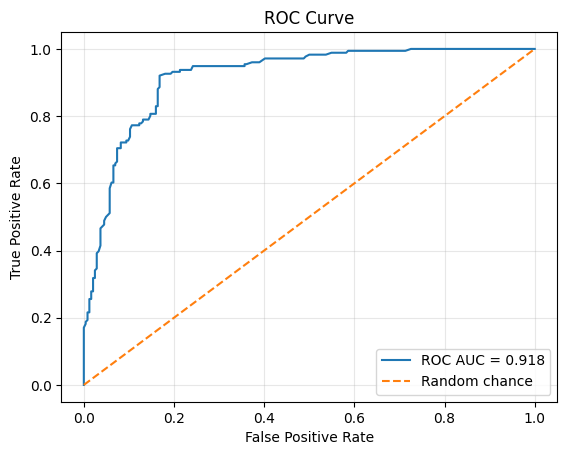

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PRECISION-RECALL (AUPRC)

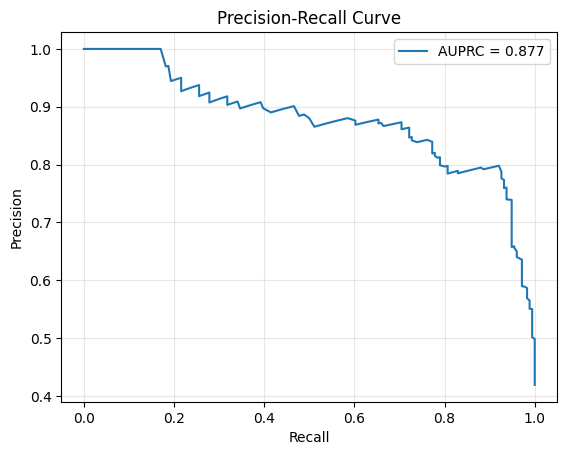

In [22]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()